<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Rainfall Forecast (Next 12 Months)
113    739.809323
114    539.585846
115    683.210418
116    537.790512
117    264.701323
118    171.667901
119    282.472670
120    360.181518
121    427.683590
122    796.752169
123    551.737486
124    586.303719
Name: predicted_mean, dtype: float64

Wet Days Prediction Performance
MAE: 2.8555649663271474
R2: 0.7640580897092769

Soil pH Prediction Performance
MAE: 0.6377522551157419
R2: -0.11692008801096931


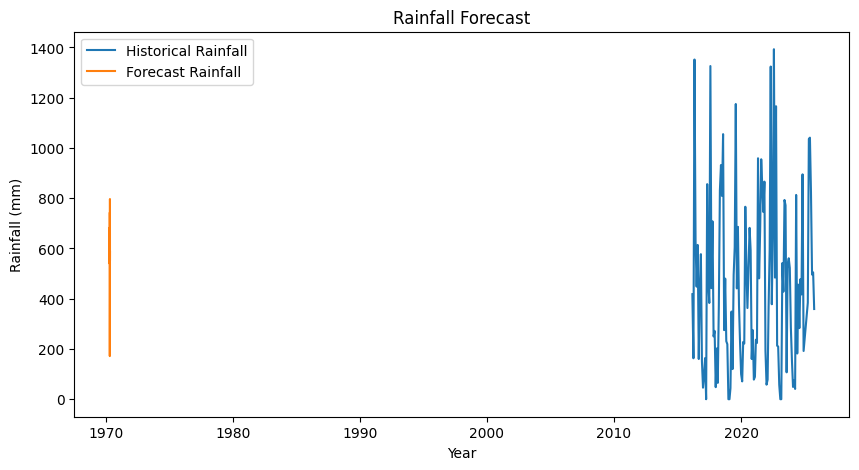

In [5]:
# ==========================================================
# STEMS - Smart Tea Estate Management System
# Rainfall Forecasting + Soil Quality Prediction
# ==========================================================

# ==========================================================
# 1. Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

from statsmodels.tsa.statespace.sarimax import SARIMAX


# ==========================================================
# 2. Load Datasets
# ==========================================================

rainfall = pd.read_csv("sample_data/rainfall_data.csv")
soil = pd.read_csv("sample_data/soil_data.csv")


# ==========================================================
# 3. Rainfall Data Preprocessing
# ==========================================================

# Convert Year column
rainfall["Year"] = rainfall["Year"].str.split("/").str[0].astype(int)

# Convert Month names to numbers
month_map = {
    "January":1,"February":2,"March":3,"April":4,
    "May":5,"June":6,"July":7,"August":8,
    "September":9,"October":10,"November":11,"December":12
}

rainfall["Month"] = rainfall["Month"].map(month_map)

# Create date column
rainfall["Date"] = pd.to_datetime(
    dict(year=rainfall.Year, month=rainfall.Month, day=1)
)

rainfall = rainfall.sort_values("Date")

# Remove missing rows
rainfall = rainfall.dropna()


# ==========================================================
# 4. Rainfall Feature Engineering
# ==========================================================

rainfall["Rainfall_lag1"] = rainfall["Rainfall"].shift(1)
rainfall["Rainfall_lag2"] = rainfall["Rainfall"].shift(2)

rainfall["WetDays_lag1"] = rainfall["Wet_days"].shift(1)

rainfall["Rainfall_3month_avg"] = rainfall["Rainfall"].rolling(3).mean()

rainfall = rainfall.dropna()


# ==========================================================
# 5. Rainfall Forecast Model (SARIMAX)
# ==========================================================

rain_series = rainfall.set_index("Date")["Rainfall"]

rain_model = SARIMAX(
    rain_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

rain_results = rain_model.fit(disp=False)

# Forecast next 12 months
rain_forecast = rain_results.forecast(steps=12)

print("\nRainfall Forecast (Next 12 Months)")
print(rain_forecast)


# ==========================================================
# 6. Wet Days Prediction Model
# ==========================================================

features = [
    "Rainfall",
    "Rainfall_lag1",
    "Rainfall_lag2",
    "Rainfall_3month_avg"
]

X = rainfall[features]
y = rainfall["Wet_days"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

wet_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

wet_model.fit(X_train, y_train)

wet_pred = wet_model.predict(X_test)

print("\nWet Days Prediction Performance")
print("MAE:", mean_absolute_error(y_test, wet_pred))
print("R2:", r2_score(y_test, wet_pred))


# ==========================================================
# 7. Soil Data Preprocessing
# ==========================================================

# Replace text missing values
soil.replace("missing", np.nan, inplace=True)

soil["pH"] = pd.to_numeric(soil["pH"], errors="coerce")
soil["C%"] = pd.to_numeric(soil["C%"], errors="coerce")
soil["Year of Planting"] = pd.to_numeric(
    soil["Year of Planting"], errors="coerce"
)

soil = soil.dropna()

# Field age
soil["FieldAge"] = 2025 - soil["Year of Planting"]

# Encode categorical variables
le = LabelEncoder()

soil["Category"] = le.fit_transform(soil["Category"])
soil["Estate"] = le.fit_transform(soil["Estate"])
soil["VP/SD"] = le.fit_transform(soil["VP/SD"])


# ==========================================================
# 8. Soil Prediction Model
# ==========================================================

soil_features = [
    "Extent (Ha)",
    "Category",
    "VP/SD",
    "FieldAge",
    "C%"
]

X_soil = soil[soil_features]
y_soil = soil["pH"]

X_train, X_test, y_train, y_test = train_test_split(
    X_soil, y_soil, test_size=0.2, random_state=42
)

soil_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=7,
    random_state=42
)

soil_model.fit(X_train, y_train)

soil_pred = soil_model.predict(X_test)

print("\nSoil pH Prediction Performance")
print("MAE:", mean_absolute_error(y_test, soil_pred))
print("R2:", r2_score(y_test, soil_pred))


# ==========================================================
# 9. Visualization
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(rain_series, label="Historical Rainfall")
plt.plot(rain_forecast, label="Forecast Rainfall")

plt.title("Rainfall Forecast")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.show()